# 05  Spine and crosswalk (DuckDB knowledge graph)

This notebook builds the base for joining unstructured and external signals onto the
shared Companies House dataset. It produces one local DuckDB database file with three tables:

- `companies`  one row per company, keyed on the Companies House number (the spine).
- `identifiers`  a crosswalk that maps each company number to its other ids and names
  (previous names, normalised name, LEI, stock ticker), each row tagged with the source it
  came from and a confidence score.
- `signals`  an empty, time stamped event table that later notebooks fill with news, hiring,
  contract wins, and other signals.

This first stage only wires up the **exact** id bridges, the ones that need no fuzzy
matching: the company's own previous names, Wikidata, and GLEIF (the LEI register). Fuzzy
name matching for sources like Contracts Finder and Adzuna jobs happens in the next notebook.

## How to reproduce (same result for everyone)
Nobody shares the `.duckdb` file. Like the big CSV it is rebuilt from this notebook.

- **Locally:** the shared `data/processed/filtered_bb_sme_sectors.zip` is already in the repo.
  Just run this notebook top to bottom.
- **In Colab via Google Drive (easiest):** put this notebook and
  `filtered_bb_sme_sectors.zip` in a Drive folder (default `MyDrive/Lloyds`), open the notebook
  with Colab, and run top to bottom. The config cell mounts Drive, reads the zip, and saves the
  built database back to the same folder so it persists. No GitHub token needed.
- **In Colab without Drive:** if the zip is not in Drive, the config cell falls back to cloning
  the repo and asks for a read-access GitHub token once.

The database lands at `data/processed/lloyds.duckdb`. It is a build artifact, so add this line
to `.gitignore` so it is never committed (teammates regenerate it):

    data/processed/*.duckdb


## 1. Install and import
DuckDB and RapidFuzz are not in the base environment. RapidFuzz is only needed by the next
notebook (fuzzy matching) but we import nothing heavy from it here. In Colab the pip line
installs them; locally, run it once or add `duckdb` and `rapidfuzz` to `requirements.txt`.

 **What we are trying to do:**

This first box makes sure two free tools are on the machine. DuckDB is a small database that lives in a single file. RapidFuzz compares two pieces of text and scores how similar they are. If they are missing it downloads them, which only happens the first time.

In [ ]:
# Run this once. Safe to re-run; pip skips what is already installed.
# In Colab this just works. Locally you can instead add these to requirements.txt.
import sys, subprocess
for pkg in ["duckdb", "rapidfuzz"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

 **Import required libraries:**

This code block switches the tools on so the rest of the notebook can use them, and prints their version numbers. pandas is a tool for working with tables of data.

In [ ]:
import duckdb
import pandas as pd
import requests
import re
from datetime import datetime, timezone

print("duckdb", duckdb.__version__)
print("pandas", pd.__version__)

duckdb 1.3.2
pandas 2.2.2


The versions used here are (DuckDB 1.3.2, pandas 2.2.2).

## 2. Config and locating the data
The cell below works out where the data is and where to write the database, for three setups:

- **Colab + Google Drive (recommended).** Put `filtered_bb_sme_sectors.zip` in a Drive folder
  (default `MyDrive/Lloyds`, change `WORK_DIR` below if yours differs). The cell mounts Drive,
  reads the zip from there, and writes the database back to the same folder so it **persists**
  between sessions. No GitHub token needed.
- **Colab without Drive.** If the zip is not found in Drive, it falls back to cloning the repo
  from GitHub and asks for a read-access token once (github.com/settings/tokens).
- **Local.** The notebook lives in `notebooks/`, so the repo root is one level up; nothing to set.

`SAMPLE_N` keeps runs quick while developing. Set it to `None` for the full ~1.37M companies.
`GLEIF_MAX_PAGES` caps the GLEIF pull (200 records per page); set to `None` to pull every UK LEI.

**Saving the result**

This next code works out where the data is and where to save the result. On Google Colab it connects to Google Drive and reads the data from there. It also sets two dials: SAMPLE_N is how many companies to use (None means all of them), and GLEIF_MAX_PAGES limits how much we download from the LEI register.

In [ ]:
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Prefer a Google Drive folder so both the data and the built database persist.
    from google.colab import drive
    drive.mount("/content/drive")
    WORK_DIR = Path("/content/drive/MyDrive/Lloyds")   # <- change to your Drive folder
    WORK_DIR.mkdir(parents=True, exist_ok=True)

    CSV_ZIP = WORK_DIR / "filtered_bb_sme_sectors.zip"
    if CSV_ZIP.exists():
        OUT_DIR = WORK_DIR
        print("using data from Drive:", CSV_ZIP)
    else:
        # Not in Drive: clone the repo from GitHub instead (asks for a token once).
        import subprocess
        from getpass import getpass
        repo = Path("/content/lloyds-commercial-banking-intelligence-2026")
        if not repo.exists():
            token = getpass("GitHub token (read access to the repo): ").strip()
            url = ("https://" + token +
                   "@github.com/Viklin41/lloyds-commercial-banking-intelligence-2026.git")
            subprocess.run(["git", "clone", "--depth", "1", url, str(repo)], check=True)
        CSV_ZIP = repo / "data" / "processed" / "filtered_bb_sme_sectors.zip"
        OUT_DIR = WORK_DIR   # still save the database to Drive so it persists
        print("zip not in Drive, cloned from GitHub:", CSV_ZIP)
else:
    REPO_ROOT = Path("..").resolve()
    CSV_ZIP = REPO_ROOT / "data" / "processed" / "filtered_bb_sme_sectors.zip"
    OUT_DIR = REPO_ROOT / "data" / "processed"

DB_PATH   = OUT_DIR / "lloyds.duckdb"
CACHE_DIR = OUT_DIR / "cache"            # cached API pulls (parquet)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_N        = None   # set to None for the full dataset
GLEIF_MAX_PAGES = 25       # 200 records/page; set to None to pull every UK LEI

# A descriptive User-Agent is required by Wikidata and is polite for GLEIF.
USER_AGENT = "LloydsBCB-MSc-project/1.0 (academic; contact via GitHub elyokerr)"

NOW = datetime.now(timezone.utc).isoformat(timespec="seconds")

print("CSV zip exists:", CSV_ZIP.exists())
print("DB path:", DB_PATH)

Mounted at /content/drive
using data from Drive: /content/drive/MyDrive/Lloyds/filtered_bb_sme_sectors.zip
CSV zip exists: True
DB path: /content/drive/MyDrive/Lloyds/lloyds.duckdb


This confirms the data file was found and shows where the database will be saved.

## 3. Small helpers
Two reusable functions: one to clean the Companies House number into a consistent key, and one
to normalise a company name (used for the `name_norm` id and, later, for fuzzy matching).

**Fix company number and name:**

This code block creates two small helper routines we reuse later. One tidies a company number so they all look the same (Companies House numbers are 8 characters, so short ones get zeros added in front). The other simplifies a company name (capital letters, no punctuation, and it drops words like LIMITED or LTD) so that 'Acme Ltd.' and 'ACME LIMITED' count as the same name.

In [ ]:
# Companies House numbers are 8 characters. Pure-digit ones can lose leading zeros when a
# tool reads them as a number, so pad those back to 8. Prefixed ones (SC, NI, OC, ...) are
# left as is.
def clean_company_number(value):
    if value is None:
        return None
    s = str(value).strip().upper()
    if s == "" or s == "NAN":
        return None
    if s.isdigit():
        return s.zfill(8)
    return s

# Common UK legal suffixes to drop so "ACME LTD" and "ACME LIMITED" normalise to the same key.
_SUFFIXES = [
    "LIMITED", "LTD", "PLC", "PUBLIC LIMITED COMPANY", "LLP",
    "LIMITED LIABILITY PARTNERSHIP", "LP", "CIC", "CIO",
    "COMPANY", "CO", "AND", "THE",
]
_SUFFIX_RE = re.compile(r"\b(" + "|".join(_SUFFIXES) + r")\b")

def normalise_name(name):
    if name is None:
        return None
    s = str(name).upper()
    s = re.sub(r"[^A-Z0-9 ]", " ", s)   # drop punctuation
    s = _SUFFIX_RE.sub(" ", s)          # drop legal suffixes
    s = re.sub(r"\s+", " ", s).strip()  # collapse spaces
    return s or None

# quick check
assert clean_company_number("123456") == "00123456"
assert clean_company_number("SC123456") == "SC123456"
assert normalise_name("Acme Holdings, Ltd.") == "ACME HOLDINGS"
print("helpers ok")

helpers ok


 **It should print helpers ok:**

It printed 'helpers ok', meaning both routines were created and passed their built-in check.

## 4. Load companies from the shared zip
Read straight from the zip. The raw Companies House file has stray leading spaces in some
column names (for example ` CompanyNumber`), so the first thing we do is strip every column
name. Then we clean the company number and keep the columns the spine needs.

 **Reading the data:**

This box opens the big data file and reads it into a table in memory. To save memory it only reads the columns we actually need. It then tidies the company number, drops any row without one, and removes duplicates so each company appears once.

In [ ]:
# Columns we keep for the spine. Previous-name columns become aliases in the crosswalk.
PREV_NAME_COLS = [f"PreviousName_{i}.CompanyName" for i in range(1, 11)]
KEEP = [
    "CompanyNumber", "CompanyName",
    "RegAddress.PostCode", "RegAddress.PostTown", "RegAddress.County",
    "CompanyStatus", "CompanyCategory", "IncorporationDate", "DissolutionDate",
    "Accounts.AccountCategory", "SICCode.SicText_1",
    "sector", "segment", "URI",
] + PREV_NAME_COLS

# usecols reads ONLY the columns we need (the callable strips the leading-space quirk before
# matching), which keeps memory low enough to run the full 1.37M rows on Colab free.
_keep_set = set(KEEP)
raw = pd.read_csv(
    CSV_ZIP, compression="zip", low_memory=False,
    nrows=SAMPLE_N, dtype=str,
    usecols=lambda c: c.strip() in _keep_set,
)
raw.columns = raw.columns.str.strip()          # fix the leading-space quirk
raw["company_number"] = raw["CompanyNumber"].map(clean_company_number)
raw = raw.dropna(subset=["company_number"]).drop_duplicates(subset=["company_number"])

print(f"companies loaded: {len(raw):,}")
raw.head(3)

companies loaded: 869,043


,CompanyName,CompanyNumber,RegAddress.PostTown,RegAddress.County,RegAddress.PostCode,CompanyCategory,CompanyStatus,DissolutionDate,IncorporationDate,Accounts.AccountCategory,...,PreviousName_4.CompanyName,PreviousName_5.CompanyName,PreviousName_6.CompanyName,PreviousName_7.CompanyName,PreviousName_8.CompanyName,PreviousName_9.CompanyName,PreviousName_10.CompanyName,sector,segment,company_number
0,!NFLECTION ADVISORY LIMITED,15073164,POTTERS BAR,HERTFORDSHIRE,EN6 2DA,Private Limited Company,Active,NaN,15/08/2023,TOTAL EXEMPTION FULL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Technology, legal & professional",BB/SME,15073164
1,!NFOGENIE LTD,13522064,LONDON,GREATER LONDON,WC2H 9JQ,Private Limited Company,Active,NaN,21/07/2021,MICRO ENTITY,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Technology, legal & professional",BB,13522064
2,!NNOV8 LIMITED,11006939,EDENBRIDGE,NaN,TN8 5NF,Private Limited Company,Active,NaN,11/10/2017,MICRO ENTITY,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fast growth & emerging,BB,11006939


**Result:**

It loaded 869,043 companies, the full dataset. Earlier test runs showed 50,000 because a smaller sample was chosen. The small preview shows the first three companies.

## 5. Create the database and the `companies` spine
**Spine just means the master list of companies, one row each, keyed on the company number**
We rebuild the database from scratch each run so the result is deterministic. The spine has one
row per company number with a few core attributes; everything else hangs off it by company
number.

 **Saving the cleaned data:**

This box makes a fresh database file and saves the cleaned company table into it as the spine. Spine just means the master list of companies, one row each, keyed on the company number. Everything else will link back to this list.

In [ ]:
# Fresh build every time: remove an old db so re-runs are reproducible.
if DB_PATH.exists():
    DB_PATH.unlink()
con = duckdb.connect(str(DB_PATH))

# normalise the current name once, for the crosswalk and for later matching
raw["name_norm"] = raw["CompanyName"].map(normalise_name)

con.execute("""
    CREATE TABLE companies AS
    SELECT
        company_number,
        CompanyName              AS company_name,
        name_norm,
        "RegAddress.PostCode"    AS postcode,
        "RegAddress.PostTown"    AS post_town,
        CompanyStatus            AS company_status,
        IncorporationDate        AS incorporation_date,
        sector,
        segment,
        URI                      AS companies_house_uri
    FROM raw
""")
n = con.execute("SELECT count(*) FROM companies").fetchone()[0]
print(f"companies table: {n:,} rows")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

companies table: 869,043 rows


**Result:**

It confirmed 869,043 rows were written to the companies table. This is our master list.

## 6. The `identifiers` crosswalk
One long table. Every way of referring to a company (its own number, a former name, an LEI, a
ticker) is a row that points back to the company number, tagged with where it came from and how
confident we are. Exact bridges get confidence 1.0; fuzzy matches later will get lower scores.

**Next:**

**The next code creates an empty crosswalk table**. A crosswalk is a translation list: it links a company to its other names and codes (its old names, its LEI, its stock ticker). It also makes a helper that adds rows, and that only keeps rows for companies that are in our master list.

In [ ]:
con.execute("""
    CREATE TABLE identifiers (
        company_number  VARCHAR,   -- the spine key it maps to
        id_type         VARCHAR,   -- companies_house | name_norm | previous_name | lei | ticker
        id_value        VARCHAR,   -- the actual id or name
        source          VARCHAR,   -- where this link came from
        confidence      DOUBLE,    -- 1.0 = exact, lower = fuzzy
        retrieved_at    VARCHAR    -- when we pulled it
    )
""")

def add_identifiers(df, id_type, source, confidence):
    """Append rows to the crosswalk. df needs columns company_number and id_value.
    Only rows for companies that exist in the spine are kept: GLEIF and Wikidata return
    every UK company, but we only care about the ones in our dataset."""
    if df is None or len(df) == 0:
        print(f"  {id_type}: nothing to add")
        return
    out = df[["company_number", "id_value"]].dropna().drop_duplicates().copy()
    out["id_type"] = id_type
    out["source"] = source
    out["confidence"] = confidence
    out["retrieved_at"] = NOW
    con.register("tmp_ids", out)
    con.execute("""INSERT INTO identifiers
                   SELECT t.company_number, t.id_type, t.id_value, t.source, t.confidence, t.retrieved_at
                   FROM tmp_ids t
                   WHERE t.company_number IN (SELECT company_number FROM companies)""")
    kept = con.execute("""SELECT count(*) FROM tmp_ids t
                   WHERE t.company_number IN (SELECT company_number FROM companies)""").fetchone()[0]
    con.unregister("tmp_ids")
    print(f"  {id_type}: +{kept:,} rows (of {len(out):,} candidates; the rest are not in our dataset)")

print("crosswalk ready")

crosswalk ready


**Result:**

It printed 'crosswalk ready', meaning the empty table and the helper are set up.

## 7. Seed the crosswalk from Companies House itself (free, offline, confidence 1.0)
Three exact links straight from the dataset we already have:
- the company number mapping to itself (so the spine is searchable in the same table),
- the normalised current name,
- every previous name the company has traded under.

:**

This box fills the crosswalk with what we already have from Companies House: the company number itself, the simplified current name, and every previous name the company has traded under. These are exact, trustworthy links.

In [ ]:
comp = con.execute("SELECT company_number, name_norm FROM companies").df()

# 7a. the number itself
self_id = comp[["company_number"]].copy()
self_id["id_value"] = self_id["company_number"]
add_identifiers(self_id, "companies_house", "companies_house", 1.0)

# 7b. normalised current name
nm = comp.rename(columns={"name_norm": "id_value"})[["company_number", "id_value"]]
add_identifiers(nm, "name_norm", "companies_house", 1.0)

# 7c. previous names (long form), normalised
prev = raw[["company_number"] + [c for c in PREV_NAME_COLS if c in raw.columns]].copy()
prev = prev.melt(id_vars="company_number", value_name="prev_name").dropna(subset=["prev_name"])
prev["id_value"] = prev["prev_name"].map(normalise_name)
add_identifiers(prev[["company_number", "id_value"]], "previous_name", "companies_house", 1.0)

  companies_house: +869,043 rows (of 869,043 candidates; the rest are not in our dataset)
  name_norm: +869,036 rows (of 869,036 candidates; the rest are not in our dataset)
  previous_name: +130,945 rows (of 130,945 candidates; the rest are not in our dataset)


✅ **What we got (and what it means):**

It added about 869,000 company numbers, 869,000 simplified names, and 130,945 previous names. So over a hundred thousand of our companies have traded under a different name at some point.

## 8. Wikidata bridge: company number to LEI and stock ticker
One SPARQL query returns every Wikidata item that has a Companies House id (property P2622),
along with its LEI (P1278) and ticker (P249) where present. This is a single request and covers
the notable, mostly listed, firms, which is exactly the Tier B set we want wired to market data.

🔹 **In plain words (what the next box does):**

This box asks Wikidata (a free public database of facts) for any UK company that lists a Companies House number, plus its LEI and stock ticker if it has them. LEI means Legal Entity Identifier, a global id for firms that trade or borrow. A ticker is the short code a company has on the stock market.

In [ ]:
WDQS = "https://query.wikidata.org/sparql"
SPARQL = """
SELECT ?chid ?lei ?ticker WHERE {
  ?company wdt:P2622 ?chid .
  OPTIONAL { ?company wdt:P1278 ?lei. }
  OPTIONAL { ?company wdt:P249  ?ticker. }
}
"""

def fetch_wikidata():
    cache = CACHE_DIR / "wikidata_chid.parquet"
    if cache.exists():
        print("  using cached Wikidata pull")
        return pd.read_parquet(cache)
    r = requests.get(
        WDQS,
        params={"query": SPARQL, "format": "json"},
        headers={"User-Agent": USER_AGENT, "Accept": "application/sparql-results+json"},
        timeout=120,
    )
    r.raise_for_status()
    rows = r.json()["results"]["bindings"]
    recs = []
    for b in rows:
        recs.append({
            "company_number": clean_company_number(b["chid"]["value"]),
            "lei":    b.get("lei", {}).get("value"),
            "ticker": b.get("ticker", {}).get("value"),
        })
    df = pd.DataFrame(recs)
    df.to_parquet(cache, index=False)
    return df

try:
    wd = fetch_wikidata()
    print(f"  Wikidata rows: {len(wd):,}")
    add_identifiers(wd.rename(columns={"lei": "id_value"}),    "lei",    "wikidata", 1.0)
    add_identifiers(wd.rename(columns={"ticker": "id_value"}), "ticker", "wikidata", 1.0)
except Exception as e:
    print("  Wikidata step skipped (network?):", e)

  using cached Wikidata pull
  Wikidata rows: 7,767
  lei: +32 rows (of 644 candidates; the rest are not in our dataset)
  ticker: +0 rows (of 2 candidates; the rest are not in our dataset)


✅ **What we got (and what it means):**

Wikidata returned 7,767 UK companies, but only 32 of them are in our dataset and have an LEI. This is the first hint that our small companies rarely have these big-company ids.

## 9. GLEIF bridge: company number to LEI for UK firms
GLEIF is the global LEI register. Every UK record carries its Companies House number in the
`registeredAs` field, so this is an exact join. We page through the GB jurisdiction records
(200 at a time) and cache the result so re-runs are instant. Set `GLEIF_MAX_PAGES = None` above
to pull the full UK set unattended.

🔹 **In plain words (what the next box does):**

This box downloads UK entries from GLEIF, the official global register of LEIs, and matches them to our companies by company number. This is an exact match, no guessing.

In [ ]:
GLEIF_URL = "https://api.gleif.org/api/v1/lei-records"

def fetch_gleif(max_pages=GLEIF_MAX_PAGES):
    cache = CACHE_DIR / "gleif_gb.parquet"
    if cache.exists():
        print("  using cached GLEIF pull")
        return pd.read_parquet(cache)
    recs, page = [], 1
    while True:
        r = requests.get(
            GLEIF_URL,
            params={"filter[entity.jurisdiction]": "GB",
                    "page[size]": 200, "page[number]": page},
            headers={"User-Agent": USER_AGENT, "Accept": "application/vnd.api+json"},
            timeout=60,
        )
        r.raise_for_status()
        body = r.json()
        for item in body.get("data", []):
            ent = item.get("attributes", {}).get("entity", {})
            recs.append({
                "company_number": clean_company_number(ent.get("registeredAs")),
                "lei": item.get("attributes", {}).get("lei"),
            })
        nxt = body.get("links", {}).get("next")
        if not nxt or (max_pages is not None and page >= max_pages):
            break
        page += 1
    df = pd.DataFrame(recs).dropna(subset=["company_number", "lei"])
    df.to_parquet(cache, index=False)
    return df

try:
    gl = fetch_gleif()
    print(f"  GLEIF rows: {len(gl):,}")
    add_identifiers(gl.rename(columns={"lei": "id_value"}), "lei", "gleif", 1.0)
except Exception as e:
    print("  GLEIF step skipped (network?):", e)

  using cached GLEIF pull
  GLEIF rows: 3,962
  lei: +823 rows (of 3,962 candidates; the rest are not in our dataset)


✅ **What we got (and what it means):**

It added 823 LEIs that belong to our companies. The download was limited to 25 pages to keep it quick, so this is a floor rather than the final total.

## 10. The `signals` table (empty for now)
The next notebook fills this with time stamped events (news mentions, job postings, contract
wins, filings). Defining it here keeps the schema in one place. Each signal points back to a
company number and carries its own source and confidence, the same provenance idea as the
crosswalk.

🔹 **In plain words (what the next box does):**

This box creates one more empty table called signals. This is where we record events about companies later, such as winning a contract or posting a job. Each event says which company, what happened, when, how much, where it came from, and how confident we are.

In [ ]:
con.execute("""
    CREATE TABLE signals (
        company_number  VARCHAR,   -- spine key
        signal_type     VARCHAR,   -- news | hiring | contract_win | grant | filing | ...
        signal_date     DATE,
        value           DOUBLE,    -- numeric payload (count, amount, sentiment, ...)
        detail          VARCHAR,   -- free text (headline, contract title, ...)
        source          VARCHAR,
        confidence      DOUBLE,
        retrieved_at    VARCHAR
    )
""")
print("signals table ready (0 rows)")

signals table ready (0 rows)


✅ **What we got (and what it means):**

It printed that the signals table is ready with 0 rows. We fill it in the next notebook.

## 11. Check coverage and save
A quick look at how many companies each bridge reached. For SMEs we expect LEI and ticker
coverage to be thin (that is the whole point: these bridges serve the larger Tier B firms, and
the SME signal sources come next). Then we close the database so the file is flushed to disk.

🔹 **In plain words (what the next box does):**

This box counts how many companies we reached with each type of identifier, and works out what share of our companies have an LEI or a stock ticker.

In [ ]:
summary = con.execute("""
    SELECT id_type, source,
           count(*)                          AS rows,
           count(DISTINCT company_number)    AS companies
    FROM identifiers
    GROUP BY id_type, source
    ORDER BY companies DESC
""").df()
print(summary.to_string(index=False))

total = con.execute("SELECT count(*) FROM companies").fetchone()[0]
def coverage(id_type):
    n = con.execute("""SELECT count(DISTINCT c.company_number)
                       FROM companies c JOIN identifiers i
                         ON i.company_number=c.company_number AND i.id_type=?""",
                    [id_type]).fetchone()[0]
    return n
n_lei, n_tic = coverage("lei"), coverage("ticker")
print(f"\ncompanies in dataset: {total:,}")
print(f"with an LEI:    {n_lei:,} ({n_lei/total:.2%})")
print(f"with a ticker:  {n_tic:,} ({n_tic/total:.2%})")
print("\nLow LEI/ticker coverage is expected: these are SMEs, which rarely hold an LEI or")
print("trade publicly. The market bridges serve the few larger firms; SME signals come from")
print("the name-matched government sources in the next notebook.")

        id_type          source   rows  companies
companies_house companies_house 869043     869043
      name_norm companies_house 869036     869036
  previous_name companies_house 130945     107776
            lei           gleif    823        823
            lei        wikidata     32         32

companies in dataset: 869,043
with an LEI:    855 (0.10%)
with a ticker:  0 (0.00%)

Low LEI/ticker coverage is expected: these are SMEs, which rarely hold an LEI or
trade publicly. The market bridges serve the few larger firms; SME signals come from
the name-matched government sources in the next notebook.


✅ **What we got (and what it means):**

The key result: only 855 of 869,043 companies (0.10 percent) have an LEI, and none have a ticker. In plain terms, almost none of our small firms appear in the big financial id systems. This matters: to learn about small companies we cannot lean on stock-market style data, we need other sources, which is the whole point of the next notebook.

🔹 **In plain words (what the next box does):**

This box pulls out a few example companies that do have an LEI or ticker, just to see the crosswalk joining up correctly.

In [ ]:
# Example join: pull the LEI and ticker for any company that has them.
example = con.execute("""
    SELECT c.company_number, c.company_name,
           lei.id_value    AS lei,
           tic.id_value    AS ticker
    FROM companies c
    LEFT JOIN identifiers lei ON lei.company_number = c.company_number AND lei.id_type='lei'
    LEFT JOIN identifiers tic ON tic.company_number = c.company_number AND tic.id_type='ticker'
    WHERE lei.id_value IS NOT NULL OR tic.id_value IS NOT NULL
    LIMIT 10
""").df()
example

,company_number,company_name,lei,ticker
0,NI633159,BROAGHCLOUGH HOLDINGS LTD,2138003ZMJXNBP1CQO75,None
1,07434479,BUBWORKS LIMITED,254900PB824N87P5DS90,None
2,10728259,BURNZEE HOLDINGS LIMITED,2138005ULRVWL4L4LO96,None
3,07725359,BURRITT CONSULTING LIMITED,98450059DF83ALA8DE48,None
4,14785335,BVDMH LIMITED,98450044AAOF8D0A4806,None
5,02403695,BVM MEDICAL LIMITED,648813B1EBR4A3QK2279,None
6,13203526,C H EASTWOOD LIMITED,9845005E5054C2D89633,None
7,13009483,C KEYE LIMITED,6488M33Q24D8FNC0H308,None
8,SC465522,CALDERVALE MACHINE TOOL ENGINEERS LTD,6488KAM817K0X50AY992,None
9,08875236,CAMBRIDGE BOWEL CLINIC LTD,984500D794PA4I91F323,None


✅ **What we got (and what it means):**

It shows a handful of companies with their LEI codes, proving the links work.

## 12. Visualise the crosswalk
Two pictures that tell the story of this notebook. Left: how many companies each identifier type
reaches. Right: the share of companies that have an external market id (LEI or ticker) versus a
former name. The point lands visually, most of our SMEs have a former name on record but almost
none have an LEI or a ticker, so external market data cannot reach them.

🔹 **In plain words (what the next box does):**

This box draws two charts. The left one shows how many companies each identifier type reaches. The right one shows the share of companies that have an external market id versus a former name.

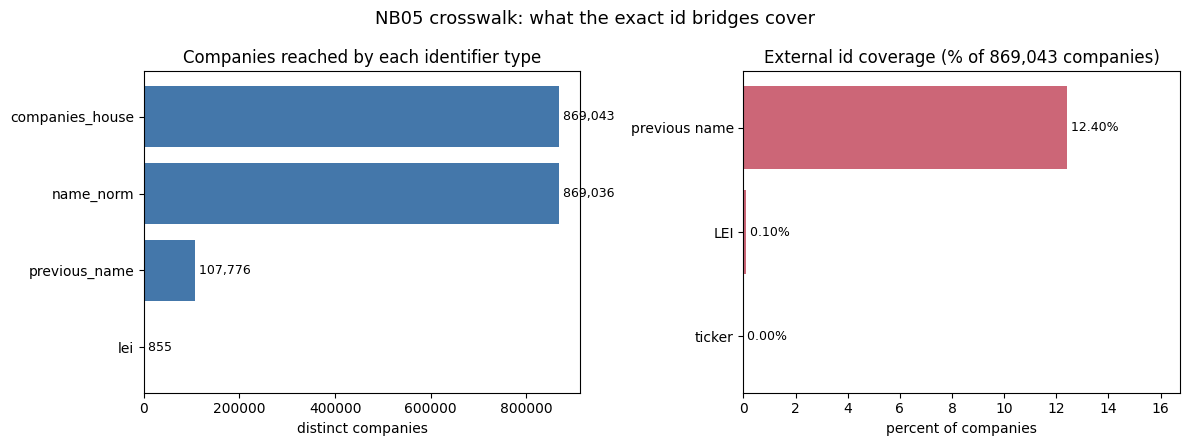

In [ ]:
import matplotlib.pyplot as plt

total = con.execute("SELECT count(*) FROM companies").fetchone()[0]

reach = con.execute("""
    SELECT id_type, count(DISTINCT company_number) AS companies
    FROM identifiers GROUP BY id_type ORDER BY companies DESC
""").df()

def share(id_type):
    n = con.execute("""SELECT count(DISTINCT c.company_number) FROM companies c
                       JOIN identifiers i ON i.company_number=c.company_number AND i.id_type=?""",
                    [id_type]).fetchone()[0]
    return 100 * n / total

cov_labels = ["previous name", "LEI", "ticker"]
cov_vals   = [share("previous_name"), share("lei"), share("ticker")]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].barh(reach["id_type"][::-1], reach["companies"][::-1], color="#4477aa")
ax[0].set_title("Companies reached by each identifier type")
ax[0].set_xlabel("distinct companies")
for i, v in enumerate(reach["companies"][::-1]):
    ax[0].text(v, i, f" {v:,}", va="center", fontsize=9)

ax[1].barh(cov_labels[::-1], cov_vals[::-1], color="#cc6677")
ax[1].set_title(f"External id coverage (% of {total:,} companies)")
ax[1].set_xlabel("percent of companies")
ax[1].set_xlim(0, max(5, max(cov_vals) * 1.35))
for i, v in enumerate(cov_vals[::-1]):
    ax[1].text(v, i, f" {v:.2f}%", va="center", fontsize=9)

fig.suptitle("NB05 crosswalk: what the exact id bridges cover", fontsize=13)
fig.tight_layout()
plt.show()

✅ **What we got (and what it means):**

The charts make the finding obvious: many companies have a former name on record (about 12 percent), but almost none have an LEI (0.1 percent) or a ticker. Easy to drop into a report.

🔹 **In plain words (what the next box does):**

This box saves and closes the database file so nothing is lost.

In [ ]:
con.close()
print(f"saved: {DB_PATH}")
print("Reminder: add  data/processed/*.duckdb  to .gitignore so this file is not committed.")

saved: /content/drive/MyDrive/Lloyds/lloyds.duckdb
Reminder: add  data/processed/*.duckdb  to .gitignore so this file is not committed.


## What the next notebook does
With the spine and exact bridges in place, notebook 06 attaches the SME-reaching signals that
are matched by name, not by a shared id:

1. Contracts Finder (public-sector contract wins) using the company number when present and the
   fuzzy matching ladder (RapidFuzz on `name_norm`, disambiguated by postcode) when not.
2. Adzuna jobs (hiring as a growth signal), aggregated to respect the free-tier limit.
3. The harmonised news features from the unstructured-data-lab branch.

Every match it writes carries a source and a confidence score, so we can always tell a clean id
join from a fuzzy name guess.